In [1]:
#imports :
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import matplotlib.pyplot as plt


In [4]:
#File upload
from google.colab import files
uploaded = files.upload()


Saving cyber-threat-intelligence_all.csv to cyber-threat-intelligence_all (1).csv


In [5]:

filename = next(iter(uploaded))
df = pd.read_csv(filename)
df.columns
df.head()
#inspecting dataset
df.info()
df.describe(include='all')
df.sample(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19940 entries, 0 to 19939
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    19940 non-null  int64  
 1   index         19464 non-null  float64
 2   text          19940 non-null  object 
 3   entities      19464 non-null  object 
 4   relations     19464 non-null  object 
 5   Comments      19464 non-null  object 
 6   id            9462 non-null   float64
 7   label         9938 non-null   object 
 8   start_offset  9462 non-null   float64
 9   end_offset    9462 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 1.5+ MB


,Unnamed: 0,index,text,entities,relations,Comments,id,label,start_offset,end_offset
17027,483,306.0,"As the report indicates, using RDP this way al...","[{'id': 44690, 'label': 'tools', 'start_offset...",[],[],44690.0,tools,98.0,101.0
13150,3418,4538.0,The harms from this industry are amply evident...,[],[],[],NaN,NaN,NaN,NaN
1311,1311,1326.0,All data is sent via HTTP POST requests.,[],[],[],NaN,NaN,NaN,NaN
534,534,545.0,"Some ransomware families, including Babuk, So...","[{'id': 46160, 'label': 'malware', 'start_offs...",[],[],46160.0,malware,44.0,54.0
7973,7973,11314.0,HYPERSCRAPE requires the victim’s account cre...,[],[],[],NaN,NaN,NaN,NaN


In [16]:
#checking missing values
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [15]:
#cleaning
df = df.drop_duplicates()
df = df.dropna(subset=['text'])  # change 'text' to your real text column
df = df.dropna(subset=['label'])
df.shape

(9866, 12)

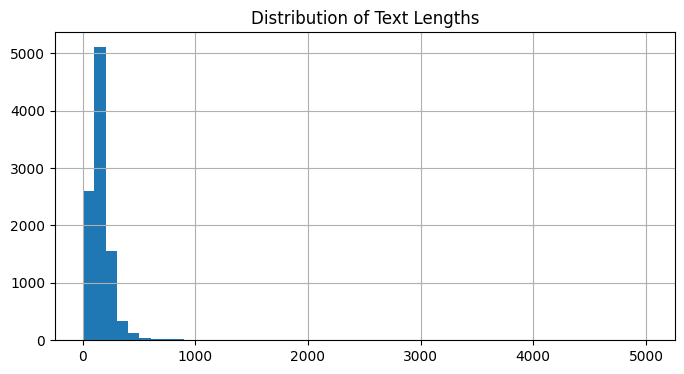

In [13]:
#text lenght analysis
df['text_len'] = df['text'].astype(str).apply(len)
df['text_len'].describe()

#Vizualisation
df['text_len'].hist(bins=50, figsize=(8,4))
plt.title("Distribution of Text Lengths")
plt.show()

In [9]:
#Text Cleaning
tqdm.pandas()

def clean_text(text):
    text = str(text).lower()

    # remove HTML
    text = re.sub(r'<.*?>', ' ', text)

    # replace URLs
    text = re.sub(r'http\S+|www\S+', ' url ', text)

    # replace IP addresses
    text = re.sub(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', ' ipaddr ', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['text'].progress_apply(clean_text)


100%|██████████| 19866/19866 [00:00<00:00, 52014.00it/s]


In [17]:
#verifying that cleaning worked
df[['text', 'clean_text']].head(10)

,text,clean_text
0,This post is also available in: 日本語 (Japa...,this post is also available in japanese ctb lo...
1,The attack vector is very basic and repeats it...,the attack vector is very basic and repeats it...
3,The first known campaign was launched by Crim...,the first known campaign was launched by crime...
5,A very serious campaign was launched between ...,a very serious campaign was launched between j...
8,Palo Alto Networks Enterprise Security Platfo...,palo alto networks enterprise security platfor...
9,We can see here that server hostnames were ch...,we can see here that server hostnames were cha...
12,"This campaign started earlier today, and the ...",this campaign started earlier today and the ma...
14,We found 147 new unique pieces of malware toda...,we found 147 new unique pieces of malware toda...
19,The other list is of last week’s campaign by t...,the other list is of last week s campaign by t...
25,It’s a subject Unit 42 has been tracking in th...,it s a subject unit 42 has been tracking in th...


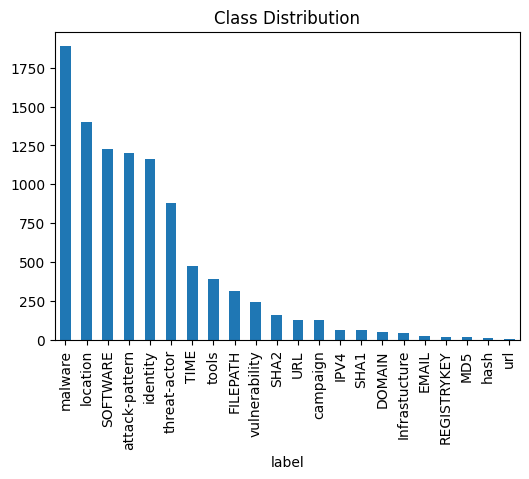

In [10]:
#class imbalance
df['label'].value_counts()
df['label'].value_counts(normalize=True) * 100
#Vizualization
df['label'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Class Distribution")
plt.show()


In [18]:
#Save & Download
df.to_csv("cleaned_dataset_v1.csv", index=False)
files.download("cleaned_dataset_v1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

print("="*80)
print("ENSEMBLE LEARNING FOR CYBER THREAT CLASSIFICATION")
print("="*80)


In [ ]:
# Extract your optimized models from GridSearch
# Update variable names based on YOUR notebook's GridSearchCV objects

try:
    # Option 1: If you used these variable names
    best_dt_model = grid_dt.best_estimator_
    best_rf_model = grid_rf.best_estimator_
    best_svm_model = grid_svm.best_estimator_
    print("✓ Models extracted!")
except NameError:
    try:
        # Option 2: Alternative naming
        best_dt_model = dt_grid.best_estimator_
        best_rf_model = rf_grid.best_estimator_
        best_svm_model = svm_grid.best_estimator_
        print("✓ Models extracted!")
    except NameError:
        print("❌ ERROR: Update variable names to match your GridSearchCV objects")
        print("Look for lines like: YOUR_VAR = GridSearchCV(...)")


In [ ]:
print("\n" + "="*80)
print("1. BAGGING WITH DECISION TREE")
print("="*80)

bagging_dt = BaggingClassifier(
    estimator=best_dt_model,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
bagging_dt.fit(X_train_vec, y_train)  # Use your vectorized training data
training_time_dt = time.time() - start_time

start_time = time.time()
y_pred_bagging_dt = bagging_dt.predict(X_test_vec)  # Use your vectorized test data
inference_time_dt = time.time() - start_time

print(f"\nTraining Time: {training_time_dt:.2f}s")
print(f"Inference Time: {inference_time_dt:.4f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging_dt))

cm_bagging_dt = confusion_matrix(y_test, y_pred_bagging_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging_dt)
disp.plot(cmap='Blues')
plt.title('Bagging Decision Tree - Confusion Matrix')
plt.show()

bagging_dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bagging_dt),
    'Precision': precision_score(y_test, y_pred_bagging_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_bagging_dt, average='weighted'),
    'F1-Macro': f1_score(y_test, y_pred_bagging_dt, average='macro'),
    'Training Time': training_time_dt,
    'Inference Time': inference_time_dt
}

print(f"\n✓ Bagging DT - F1-Macro: {bagging_dt_metrics['F1-Macro']:.4f}")


In [ ]:
print("\n" + "="*80)
print("2. BAGGING WITH SVM")
print("="*80)

bagging_svm = BaggingClassifier(
    estimator=best_svm_model,
    n_estimators=30,
    max_samples=0.7,
    max_features=0.9,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
bagging_svm.fit(X_train_vec, y_train)
training_time_svm = time.time() - start_time

start_time = time.time()
y_pred_bagging_svm = bagging_svm.predict(X_test_vec)
inference_time_svm = time.time() - start_time

print(f"\nTraining Time: {training_time_svm:.2f}s")
print(f"Inference Time: {inference_time_svm:.4f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging_svm))

cm_bagging_svm = confusion_matrix(y_test, y_pred_bagging_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging_svm)
disp.plot(cmap='Oranges')
plt.title('Bagging SVM - Confusion Matrix')
plt.show()

bagging_svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bagging_svm),
    'Precision': precision_score(y_test, y_pred_bagging_svm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_bagging_svm, average='weighted'),
    'F1-Macro': f1_score(y_test, y_pred_bagging_svm, average='macro'),
    'Training Time': training_time_svm,
    'Inference Time': inference_time_svm
}

print(f"\n✓ Bagging SVM - F1-Macro: {bagging_svm_metrics['F1-Macro']:.4f}")


In [ ]:
print("\n" + "="*80)
print("3. VOTING CLASSIFIER")
print("="*80)

voting_clf = VotingClassifier(
    estimators=[
        ('random_forest', best_rf_model),
        ('decision_tree', best_dt_model),
        ('svm', best_svm_model)
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

start_time = time.time()
voting_clf.fit(X_train_vec, y_train)
training_time_voting = time.time() - start_time

start_time = time.time()
y_pred_voting = voting_clf.predict(X_test_vec)
inference_time_voting = time.time() - start_time

print(f"\nTraining Time: {training_time_voting:.2f}s")
print(f"Inference Time: {inference_time_voting:.4f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

cm_voting = confusion_matrix(y_test, y_pred_voting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_voting)
disp.plot(cmap='Greens')
plt.title('Voting Classifier - Confusion Matrix')
plt.show()

voting_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting, average='weighted'),
    'Recall': recall_score(y_test, y_pred_voting, average='weighted'),
    'F1-Macro': f1_score(y_test, y_pred_voting, average='macro'),
    'Training Time': training_time_voting,
    'Inference Time': inference_time_voting
}

print(f"\n✓ Voting - F1-Macro: {voting_metrics['F1-Macro']:.4f}")


In [ ]:
print("\n" + "="*80)
print("4. STACKING CLASSIFIER")
print("="*80)

from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('dt', best_dt_model),
        ('svm', best_svm_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1
)

start_time = time.time()
stacking_clf.fit(X_train_vec, y_train)
training_time_stacking = time.time() - start_time

start_time = time.time()
y_pred_stacking = stacking_clf.predict(X_test_vec)
inference_time_stacking = time.time() - start_time

print(f"\nTraining Time: {training_time_stacking:.2f}s")
print(f"Inference Time: {inference_time_stacking:.4f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacking))

cm_stacking = confusion_matrix(y_test, y_pred_stacking)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stacking)
disp.plot(cmap='Purples')
plt.title('Stacking Classifier - Confusion Matrix')
plt.show()

stacking_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_stacking),
    'Precision': precision_score(y_test, y_pred_stacking, average='weighted'),
    'Recall': recall_score(y_test, y_pred_stacking, average='weighted'),
    'F1-Macro': f1_score(y_test, y_pred_stacking, average='macro'),
    'Training Time': training_time_stacking,
    'Inference Time': inference_time_stacking
}

print(f"\n✓ Stacking - F1-Macro: {stacking_metrics['F1-Macro']:.4f}")


In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Decision Tree',
        'SVM',
        'Bagging + DT',
        'Bagging + SVM',
        'Voting',
        'Stacking'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm),
        bagging_dt_metrics['Accuracy'],
        bagging_svm_metrics['Accuracy'],
        voting_metrics['Accuracy'],
        stacking_metrics['Accuracy']
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        bagging_dt_metrics['Precision'],
        bagging_svm_metrics['Precision'],
        voting_metrics['Precision'],
        stacking_metrics['Precision']
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        bagging_dt_metrics['Recall'],
        bagging_svm_metrics['Recall'],
        voting_metrics['Recall'],
        stacking_metrics['Recall']
    ],
    'F1-Macro': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        bagging_dt_metrics['F1-Macro'],
        bagging_svm_metrics['F1-Macro'],
        voting_metrics['F1-Macro'],
        stacking_metrics['F1-Macro']
    ]
})

print(comparison_results.to_string(index=False))
print("="*80)

best_idx = comparison_results['F1-Macro'].idxmax()
print(f"\n🏆 BEST MODEL: {comparison_results.loc[best_idx, 'Model']}")
print(f"   F1-Macro: {comparison_results.loc[best_idx, 'F1-Macro']:.4f}")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = comparison_results['Model']
f1_scores = comparison_results['F1-Macro']

axes[0, 0].barh(models, f1_scores, color='steelblue')
axes[0, 0].set_xlabel('F1-Macro')
axes[0, 0].set_title('F1-Macro Comparison - Cyber Threat Classification')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(f1_scores):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

axes[0, 1].scatter(comparison_results['Accuracy'], comparison_results['Precision'], 
                   s=200, alpha=0.6, c=range(len(models)), cmap='viridis')
for i, txt in enumerate(models):
    axes[0, 1].annotate(txt, (comparison_results['Accuracy'][i], 
                         comparison_results['Precision'][i]), fontsize=8, ha='center')
axes[0, 1].set_xlabel('Accuracy')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Accuracy vs Precision')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].bar(range(len(models)), comparison_results['Recall'], color='coral', alpha=0.7)
axes[1, 0].set_xticks(range(len(models)))
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall Comparison')
axes[1, 0].grid(axis='y', alpha=0.3)

from math import pi
ensemble_models = ['Bagging + DT', 'Bagging + SVM', 'Voting', 'Stacking']
ensemble_data = comparison_results[comparison_results['Model'].isin(ensemble_models)]
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(2, 2, 4, projection='polar')
for idx, model in enumerate(ensemble_data['Model']):
    values = ensemble_data[ensemble_data['Model'] == model][categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Ensemble Models Performance', size=11, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "="*80)
print("CYBERSECURITY INSIGHTS - THREAT INTELLIGENCE CLASSIFICATION")
print("="*80)

best_recall = comparison_results['Recall'].idxmax()
best_precision = comparison_results['Precision'].idxmax()
best_balanced = comparison_results['F1-Macro'].idxmax()

print(f"\nBEST FOR THREAT DETECTION (Recall): {comparison_results.loc[best_recall, 'Model']}")
print(f"BEST FOR PRECISION: {comparison_results.loc[best_precision, 'Model']}")
print(f"BEST OVERALL: {comparison_results.loc[best_balanced, 'Model']}")

print("\n" + "="*80)
print("DEPLOYMENT RECOMMENDATIONS:")
print("1. Use ensemble models for production threat intelligence systems")
print("2. High recall critical for detecting emerging threats")
print("3. Combine with human analyst validation for high-confidence alerts")
print("="*80)
